In [ ]:
# B - Statistical Analysis

#This  notebook performs statistical analysis on the processed Formula 1 tyre strategy dataset.

## Goals
#Compute average lap time by compound, driver, and team
#Analyze stint lengths
#Identify fastest and slowest laps
#Study tyre degradation trends
#Generate tables and figures for the research paper

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [3]:
DATA_PATH = Path("../data/processed/master_dataset.csv")
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully
Shape: (11880, 14)


,Driver,Team,LapNumber,Compound,TyreLife,Stint,Position,TrackStatus,LapTimeSeconds,FuelLoadApprox,StintProgress,CompoundEncoded,FreshTyre,TyreAgeSquared
0,VER,Red Bull Racing,1.0,SOFT,4.0,1.0,2.0,1,83.186,0.984848,0.100,0,0,16.0
1,VER,Red Bull Racing,2.0,SOFT,5.0,1.0,2.0,1,79.871,0.969697,0.125,0,0,25.0
2,VER,Red Bull Racing,3.0,SOFT,6.0,1.0,1.0,1,79.364,0.954545,0.150,0,0,36.0
3,VER,Red Bull Racing,4.0,SOFT,7.0,1.0,1.0,1,80.766,0.939394,0.175,0,0,49.0
4,VER,Red Bull Racing,5.0,SOFT,8.0,1.0,1.0,1,80.827,0.924242,0.200,0,0,64.0


In [4]:
print("Columns:")
for col in df.columns:
    print("-", col)

Columns:
- Driver
- Team
- LapNumber
- Compound
- TyreLife
- Stint
- Position
- TrackStatus
- LapTimeSeconds
- FuelLoadApprox
- StintProgress
- CompoundEncoded
- FreshTyre
- TyreAgeSquared


In [5]:
tables_path = Path("../outputs/tables")
figures_path = Path("../outputs/figures")

tables_path.mkdir(parents=True, exist_ok=True)
figures_path.mkdir(parents=True, exist_ok=True)

In [6]:
avg_lap_by_compound = (
    df.groupby("Compound")["LapTimeSeconds"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .sort_values("mean")
)

display(avg_lap_by_compound)
avg_lap_by_compound.to_csv(tables_path / "avg_lap_by_compound.csv")

,count,mean,median,std,min,max
Compound,,,,,,
MEDIUM,3845,91.701318,88.395,9.406630,78.069,149.129
HARD,4896,91.973201,95.449,8.785716,78.083,138.694
SOFT,3139,92.381558,91.751,9.407607,76.330,145.466


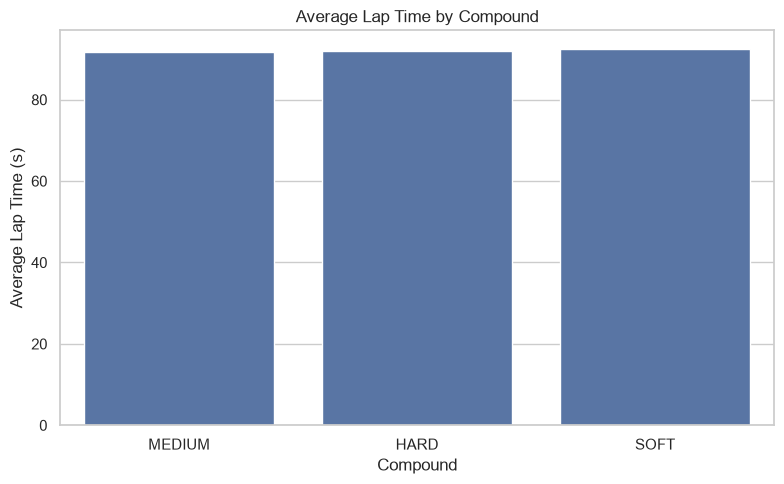

In [7]:
plt.figure(figsize=(8,5))
sns.barplot(
    x=avg_lap_by_compound.index,
    y=avg_lap_by_compound["mean"]
)
plt.title("Average Lap Time by Compound")
plt.xlabel("Compound")
plt.ylabel("Average Lap Time (s)")
plt.tight_layout()
plt.savefig(figures_path / "avg_lap_by_compound.png", dpi=300)
plt.show()

In [8]:
avg_lap_by_driver = (
    df.groupby("Driver")["LapTimeSeconds"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .sort_values("mean")
)

display(avg_lap_by_driver.head(10))
avg_lap_by_driver.to_csv(tables_path / "avg_lap_by_driver.csv")

,count,mean,median,std,min,max
Driver,,,,,,
DEV,160,89.314769,87.2320,9.040475,78.594,121.184
PIA,410,90.047549,87.1560,8.943704,77.874,122.071
VER,628,91.133865,88.3645,9.352361,76.330,138.778
SAR,332,91.251994,87.9420,9.056835,79.247,132.438
SAI,630,91.398952,88.7470,8.800900,78.403,119.006
LEC,578,91.456439,88.9375,9.391440,77.897,147.541
PER,624,91.574410,89.2585,9.010995,76.666,119.337
HAM,630,91.605140,89.7535,9.187140,76.676,123.697
ALO,592,91.617350,89.7910,8.375343,78.083,120.922


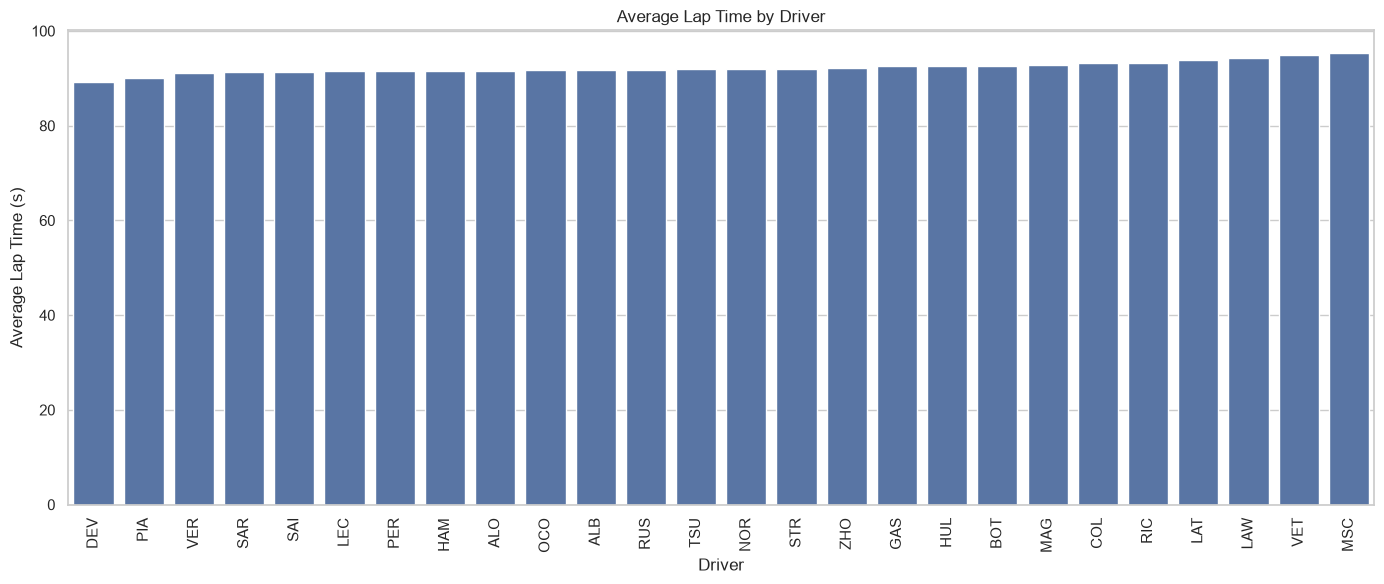

In [9]:
plt.figure(figsize=(14,6))
sns.barplot(
    x=avg_lap_by_driver.index,
    y=avg_lap_by_driver["mean"]
)
plt.title("Average Lap Time by Driver")
plt.xlabel("Driver")
plt.ylabel("Average Lap Time (s)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(figures_path / "avg_lap_by_driver.png", dpi=300)
plt.show()

In [10]:
avg_lap_by_team = (
    df.groupby("Team")["LapTimeSeconds"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .sort_values("mean")
)

display(avg_lap_by_team)
avg_lap_by_team.to_csv(tables_path / "avg_lap_by_team.csv")

,count,mean,median,std,min,max
Team,,,,,,
Red Bull Racing,1252,91.353434,88.6725,9.182783,76.330,138.778
Ferrari,1208,91.426459,88.8135,9.084507,77.897,147.541
Kick Sauber,463,91.610333,96.3650,8.466091,78.771,121.081
Mercedes,1262,91.724307,89.3795,9.546767,76.676,145.466
Alpine,1156,91.814343,89.5855,8.876434,78.375,138.694
McLaren,1207,91.841183,89.6210,9.515938,77.115,129.886
Williams,1148,91.917922,90.0915,8.465623,79.132,133.278
RB,420,92.212055,96.5365,8.939909,79.447,121.124
Aston Martin,1158,92.310274,90.5160,9.202282,78.083,123.711


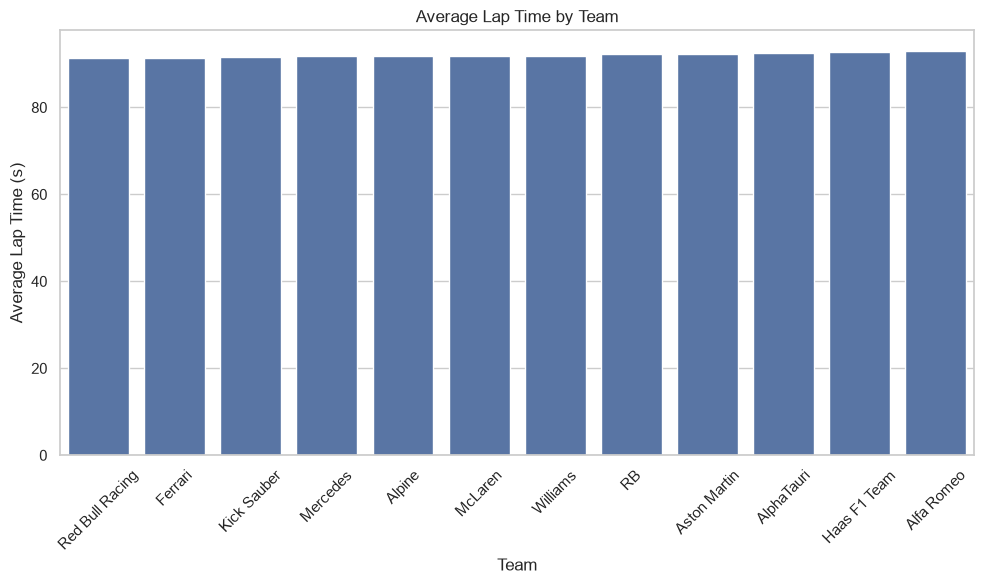

In [11]:
plt.figure(figsize=(10,6))
sns.barplot(
    x=avg_lap_by_team.index,
    y=avg_lap_by_team["mean"]
)
plt.title("Average Lap Time by Team")
plt.xlabel("Team")
plt.ylabel("Average Lap Time (s)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(figures_path / "avg_lap_by_team.png", dpi=300)
plt.show()

In [12]:
stint_stats = (
    df.groupby(["Driver", "Stint"])
      .agg(
          Team=("Team", "first"),
          Compound=("Compound", "first"),
          StintLength=("LapNumber", "count"),
          AvgLapTime=("LapTimeSeconds", "mean"),
          AvgTyreLife=("TyreLife", "mean")
      )
      .reset_index()
)

display(stint_stats.head())
stint_stats.to_csv(tables_path / "stint_stats.csv", index=False)

,Driver,Stint,Team,Compound,StintLength,AvgLapTime,AvgTyreLife
0,ALB,1.0,Williams,MEDIUM,135,92.786348,8.614815
1,ALB,2.0,Williams,SOFT,213,91.531075,13.915493
2,ALB,3.0,Williams,SOFT,121,90.293554,11.000000
3,ALB,4.0,Williams,MEDIUM,30,96.138633,8.233333
4,ALB,5.0,Williams,SOFT,10,91.324100,8.500000


In [13]:
avg_stint_by_compound = (
    stint_stats.groupby("Compound")["StintLength"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .sort_values("mean", ascending=False)
)

display(avg_stint_by_compound)
avg_stint_by_compound.to_csv(tables_path / "avg_stint_by_compound.csv")

,count,mean,median,std,min,max
Compound,,,,,,
MEDIUM,30,155.200000,166.0,98.389935,17,309
HARD,17,116.823529,126.0,47.745727,8,191
SOFT,55,95.236364,79.0,75.880990,1,260


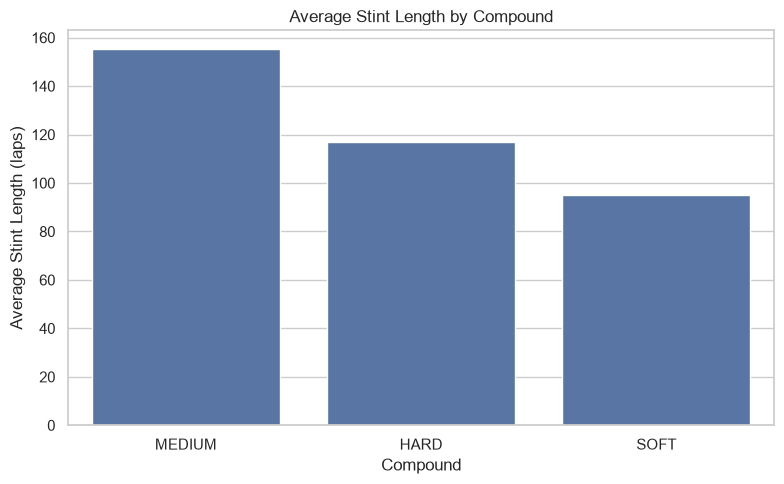

In [14]:
plt.figure(figsize=(8,5))
sns.barplot(
    x=avg_stint_by_compound.index,
    y=avg_stint_by_compound["mean"]
)
plt.title("Average Stint Length by Compound")
plt.xlabel("Compound")
plt.ylabel("Average Stint Length (laps)")
plt.tight_layout()
plt.savefig(figures_path / "avg_stint_by_compound.png", dpi=300)
plt.show()

In [15]:
avg_stint_by_driver = (
    stint_stats.groupby("Driver")["StintLength"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .sort_values("mean", ascending=False)
)

display(avg_stint_by_driver.head(10))
avg_stint_by_driver.to_csv(tables_path / "avg_stint_by_driver.csv")

,count,mean,median,std,min,max
Driver,,,,,,
HAM,4,157.50,168.5,101.062687,24,269
SAI,4,157.50,147.0,117.025638,27,309
VER,4,157.00,178.0,97.962578,28,244
PER,4,156.00,163.5,97.245394,37,260
GAS,4,154.75,155.0,87.018676,48,261
MAG,4,154.25,169.0,81.810248,44,235
BOT,4,153.75,185.5,104.767600,6,238
ALO,4,148.00,166.0,93.352379,20,240
LEC,4,144.50,145.0,118.517228,6,282


In [16]:
fastest_laps = df.nsmallest(10, "LapTimeSeconds")[
    ["Driver", "Team", "LapNumber", "Compound", "TyreLife", "LapTimeSeconds"]
]

display(fastest_laps)
fastest_laps.to_csv(tables_path / "fastest_laps_top10.csv", index=False)

,Driver,Team,LapNumber,Compound,TyreLife,LapTimeSeconds
2546,VER,Red Bull Racing,61.0,SOFT,11.0,76.330
2735,PER,Red Bull Racing,52.0,SOFT,2.0,76.666
2613,HAM,Mercedes,62.0,SOFT,15.0,76.676
116,NOR,McLaren,51.0,SOFT,7.0,77.115
2736,PER,Red Bull Racing,53.0,SOFT,3.0,77.122
3592,NOR,McLaren,55.0,SOFT,8.0,77.182
2541,VER,Red Bull Racing,56.0,SOFT,6.0,77.183
3590,NOR,McLaren,53.0,SOFT,6.0,77.287
2542,VER,Red Bull Racing,57.0,SOFT,7.0,77.306
114,NOR,McLaren,49.0,SOFT,5.0,77.377


In [17]:
slowest_laps = df.nlargest(10, "LapTimeSeconds")[
    ["Driver", "Team", "LapNumber", "Compound", "TyreLife", "LapTimeSeconds"]
]

display(slowest_laps)
slowest_laps.to_csv(tables_path / "slowest_laps_top10.csv", index=False)

,Driver,Team,LapNumber,Compound,TyreLife,LapTimeSeconds
6070,GAS,AlphaTauri,34.0,MEDIUM,1.0,149.129
6111,LEC,Ferrari,35.0,MEDIUM,1.0,147.541
6296,RUS,Mercedes,42.0,SOFT,1.0,145.466
6051,VER,Red Bull Racing,41.0,SOFT,1.0,138.778
9831,OCO,Alpine,33.0,HARD,1.0,138.694
6306,RUS,Mercedes,52.0,SOFT,1.0,136.484
9814,OCO,Alpine,16.0,HARD,4.0,135.708
2463,MAG,Haas F1 Team,50.0,SOFT,1.0,134.785
6050,VER,Red Bull Racing,40.0,MEDIUM,5.0,133.541
2485,ALB,Williams,15.0,HARD,4.0,133.278


In [18]:
best_lap_per_driver = (
    df.groupby("Driver")["LapTimeSeconds"]
    .min()
    .sort_values()
    .reset_index(name="BestLapTime")
)

display(best_lap_per_driver)
best_lap_per_driver.to_csv(tables_path / "best_lap_per_driver.csv", index=False)

,Driver,BestLapTime
0,VER,76.330
1,PER,76.666
2,HAM,76.676
3,NOR,77.115
4,PIA,77.874
5,RUS,77.875
6,LEC,77.897
7,MAG,78.069
8,ALO,78.083
9,BOT,78.242


In [19]:
best_lap_per_team = (
    df.groupby("Team")["LapTimeSeconds"]
    .min()
    .sort_values()
    .reset_index(name="BestLapTime")
)

display(best_lap_per_team)
best_lap_per_team.to_csv(tables_path / "best_lap_per_team.csv", index=False)

,Team,BestLapTime
0,Red Bull Racing,76.330
1,Mercedes,76.676
2,McLaren,77.115
3,Ferrari,77.897
4,Haas F1 Team,78.069
5,Aston Martin,78.083
6,Alfa Romeo,78.242
7,Alpine,78.375
8,AlphaTauri,78.594
9,Kick Sauber,78.771


In [20]:
degradation_by_compound = (
    df.groupby(["Compound", "TyreLife"])["LapTimeSeconds"]
    .mean()
    .reset_index()
)

display(degradation_by_compound.head())
degradation_by_compound.to_csv(tables_path / "degradation_by_compound.csv", index=False)

,Compound,TyreLife,LapTimeSeconds
0,HARD,1.0,112.792366
1,HARD,2.0,92.589882
2,HARD,3.0,92.222831
3,HARD,4.0,92.976663
4,HARD,5.0,91.799602


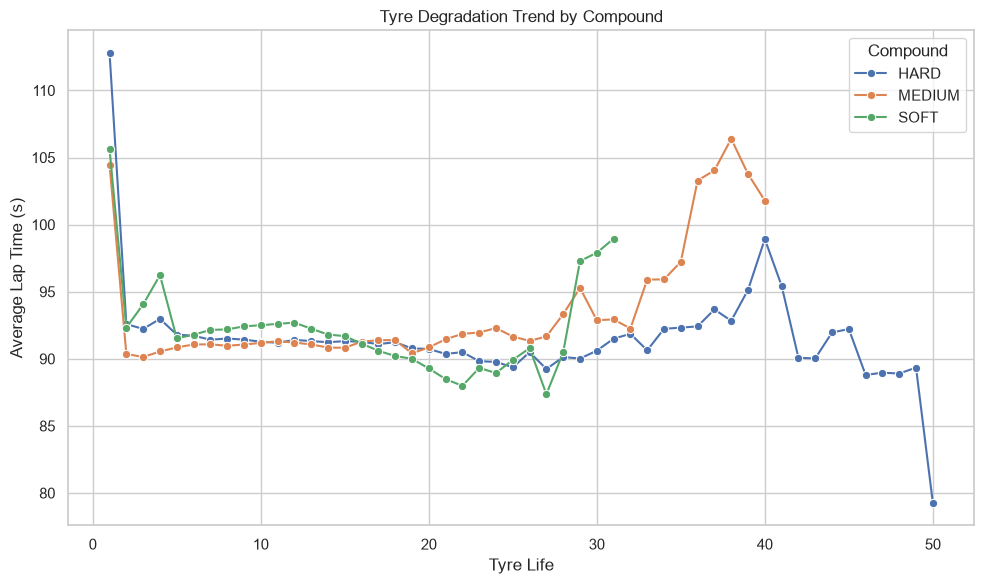

In [21]:
plt.figure(figsize=(10,6))
sns.lineplot(
    data=degradation_by_compound,
    x="TyreLife",
    y="LapTimeSeconds",
    hue="Compound",
    marker="o"
)
plt.title("Tyre Degradation Trend by Compound")
plt.xlabel("Tyre Life")
plt.ylabel("Average Lap Time (s)")
plt.tight_layout()
plt.savefig(figures_path / "degradation_by_compound.png", dpi=300)
plt.show()

In [22]:
driver_degradation = (
    df.groupby(["Driver", "TyreLife"])["LapTimeSeconds"]
    .mean()
    .reset_index()
)

display(driver_degradation.head())
driver_degradation.to_csv(tables_path / "driver_degradation.csv", index=False)

,Driver,TyreLife,LapTimeSeconds
0,ALB,1.0,106.789833
1,ALB,2.0,90.889409
2,ALB,3.0,93.565769
3,ALB,4.0,94.750276
4,ALB,5.0,92.133448


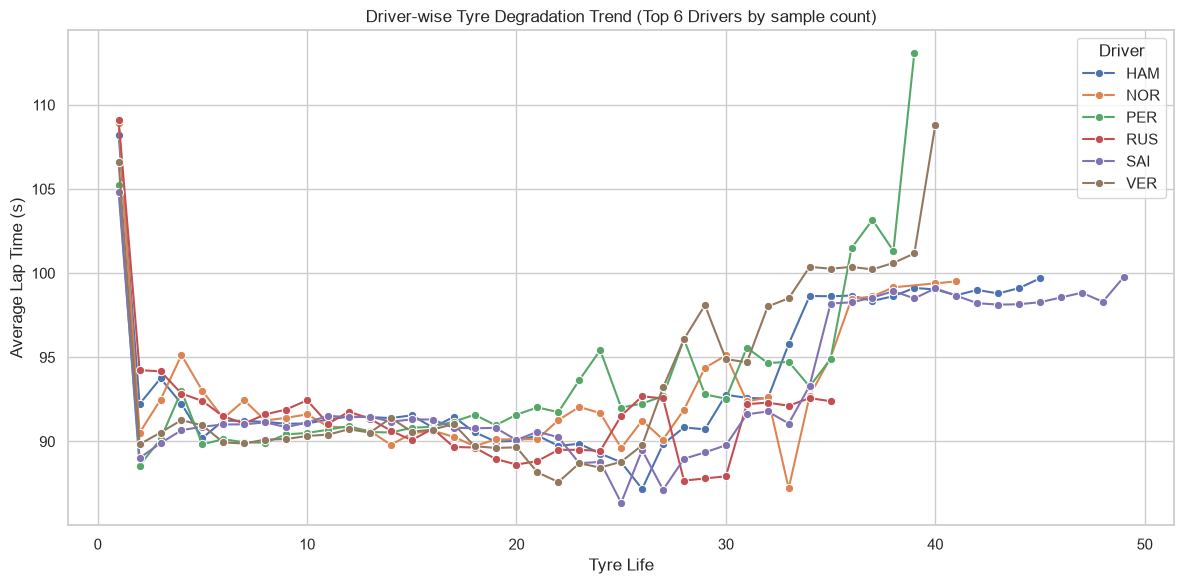

In [23]:
top_drivers = df["Driver"].value_counts().head(6).index
driver_deg_subset = driver_degradation[driver_degradation["Driver"].isin(top_drivers)]

plt.figure(figsize=(12,6))
sns.lineplot(
    data=driver_deg_subset,
    x="TyreLife",
    y="LapTimeSeconds",
    hue="Driver",
    marker="o"
)
plt.title("Driver-wise Tyre Degradation Trend (Top 6 Drivers by sample count)")
plt.xlabel("Tyre Life")
plt.ylabel("Average Lap Time (s)")
plt.tight_layout()
plt.savefig(figures_path / "driver_degradation_top6.png", dpi=300)
plt.show()

In [24]:
team_degradation = (
    df.groupby(["Team", "TyreLife"])["LapTimeSeconds"]
    .mean()
    .reset_index()
)

display(team_degradation.head())
team_degradation.to_csv(tables_path / "team_degradation.csv", index=False)

,Team,TyreLife,LapTimeSeconds
0,Alfa Romeo,1.0,108.666840
1,Alfa Romeo,2.0,90.148880
2,Alfa Romeo,3.0,91.671000
3,Alfa Romeo,4.0,94.901286
4,Alfa Romeo,5.0,92.056432


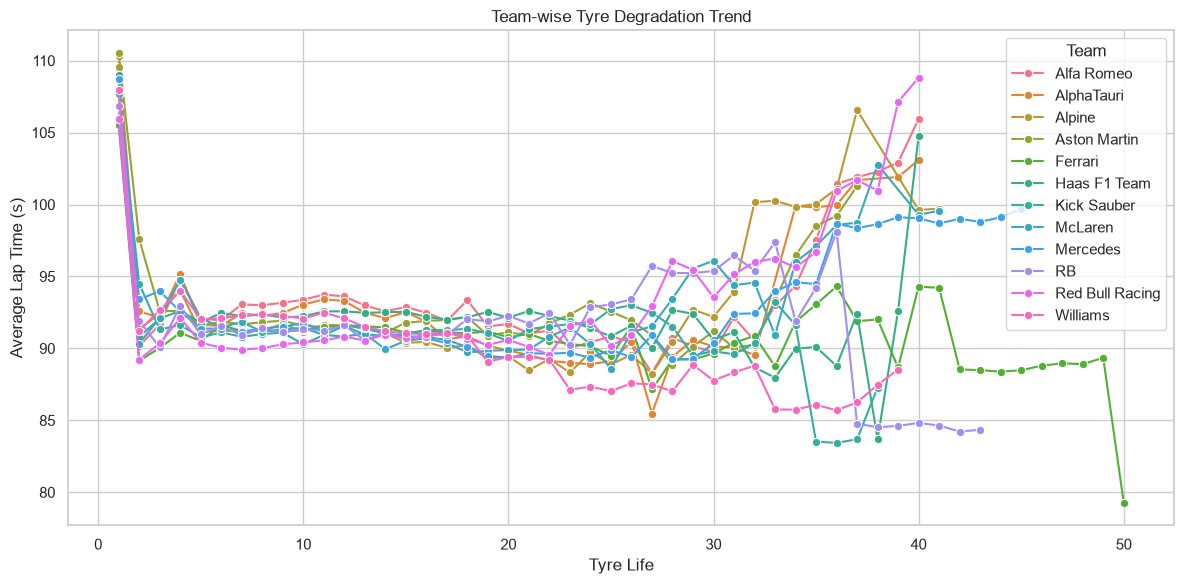

In [25]:
plt.figure(figsize=(12,6))
sns.lineplot(
    data=team_degradation,
    x="TyreLife",
    y="LapTimeSeconds",
    hue="Team",
    marker="o"
)
plt.title("Team-wise Tyre Degradation Trend")
plt.xlabel("Tyre Life")
plt.ylabel("Average Lap Time (s)")
plt.tight_layout()
plt.savefig(figures_path / "team_degradation.png", dpi=300)
plt.show()

In [26]:
avg_lap_fresh = (
    df.groupby("FreshTyre")["LapTimeSeconds"]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

display(avg_lap_fresh)
avg_lap_fresh.to_csv(tables_path / "avg_lap_by_fresh_tyre.csv")

,count,mean,median,std,min,max
FreshTyre,,,,,,
0,11504,91.467195,89.4585,8.564700,76.330,135.708
1,376,108.083665,107.0900,11.795757,83.935,149.129


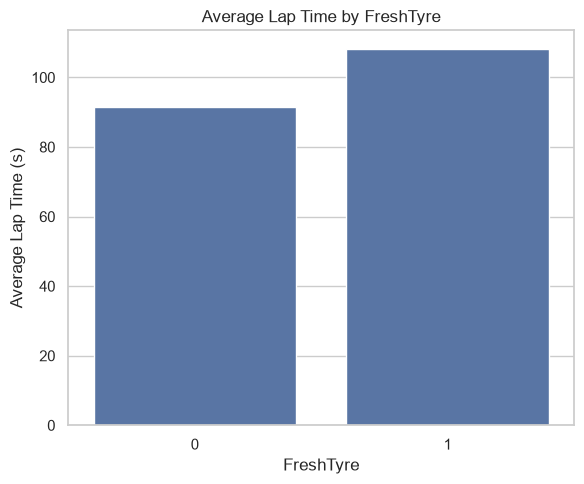

In [27]:
plt.figure(figsize=(6,5))
sns.barplot(
    x=avg_lap_fresh.index.astype(str),
    y=avg_lap_fresh["mean"]
)
plt.title("Average Lap Time by FreshTyre")
plt.xlabel("FreshTyre")
plt.ylabel("Average Lap Time (s)")
plt.tight_layout()
plt.savefig(figures_path / "avg_lap_by_fresh_tyre.png", dpi=300)
plt.show()

In [28]:
avg_lap_by_position = (
    df.groupby("Position")["LapTimeSeconds"]
    .mean()
    .reset_index()
    .sort_values("Position")
)

display(avg_lap_by_position)
avg_lap_by_position.to_csv(tables_path / "avg_lap_by_position.csv", index=False)

,Position,LapTimeSeconds
0,1.0,90.689269
1,2.0,90.906979
2,3.0,91.091857
3,4.0,91.334122
4,5.0,91.387447
5,6.0,91.583396
6,7.0,91.886019
7,8.0,92.057092
8,9.0,92.082786
9,10.0,92.415406


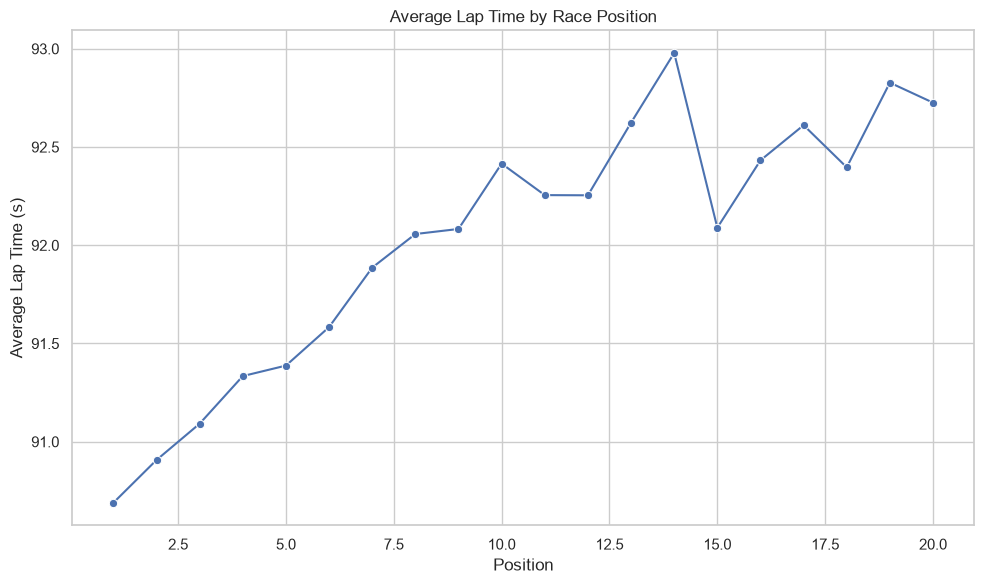

In [29]:
plt.figure(figsize=(10,6))
sns.lineplot(
    data=avg_lap_by_position,
    x="Position",
    y="LapTimeSeconds",
    marker="o"
)
plt.title("Average Lap Time by Race Position")
plt.xlabel("Position")
plt.ylabel("Average Lap Time (s)")
plt.tight_layout()
plt.savefig(figures_path / "avg_lap_by_position.png", dpi=300)
plt.show()

In [30]:
avg_lap_by_track = (
    df.groupby("TrackStatus")["LapTimeSeconds"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .sort_values("mean")
)

display(avg_lap_by_track)
avg_lap_by_track.to_csv(tables_path / "avg_lap_by_track_status.csv")

,count,mean,median,std,min,max
TrackStatus,,,,,,
1,11880,91.993103,89.99,9.159013,76.33,149.129


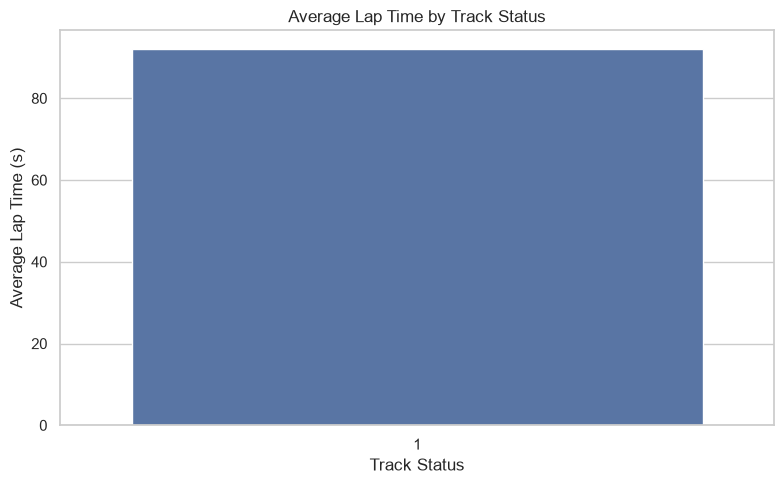

In [31]:
plt.figure(figsize=(8,5))
sns.barplot(
    x=avg_lap_by_track.index.astype(str),
    y=avg_lap_by_track["mean"]
)
plt.title("Average Lap Time by Track Status")
plt.xlabel("Track Status")
plt.ylabel("Average Lap Time (s)")
plt.tight_layout()
plt.savefig(figures_path / "avg_lap_by_track_status.png", dpi=300)
plt.show()

In [32]:
print("Quick Statistical Insights")
print("-" * 40)

print("\nBest average compound performance:")
print(avg_lap_by_compound["mean"].idxmin(), "with average lap time", round(avg_lap_by_compound["mean"].min(), 3))

print("\nWorst average compound performance:")
print(avg_lap_by_compound["mean"].idxmax(), "with average lap time", round(avg_lap_by_compound["mean"].max(), 3))

print("\nDriver with best average lap time:")
print(avg_lap_by_driver["mean"].idxmin(), "with average lap time", round(avg_lap_by_driver["mean"].min(), 3))

print("\nTeam with best average lap time:")
print(avg_lap_by_team["mean"].idxmin(), "with average lap time", round(avg_lap_by_team["mean"].min(), 3))

print("\nAverage stint length by compound:")
display(avg_stint_by_compound[["mean"]])

Quick Statistical Insights
----------------------------------------

Best average compound performance:
MEDIUM with average lap time 91.701

Worst average compound performance:
SOFT with average lap time 92.382

Driver with best average lap time:
DEV with average lap time 89.315

Team with best average lap time:
Red Bull Racing with average lap time 91.353

Average stint length by compound:


,mean
Compound,
MEDIUM,155.200000
HARD,116.823529
SOFT,95.236364
